In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
sns.set_style('whitegrid')

In [2]:
dataset = pd.read_csv('C:\sam\day7\Mall_Customers.csv')
dataset.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\User\AppData\Local\Temp\ipykernel_8972\3219644151.py:1: SyntaxWarning: invalid escape sequence '\s'
  dataset = pd.read_csv('C:\sam\day7\Mall_Customers.csv')


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
x = dataset.iloc[:, [3, 4]].values

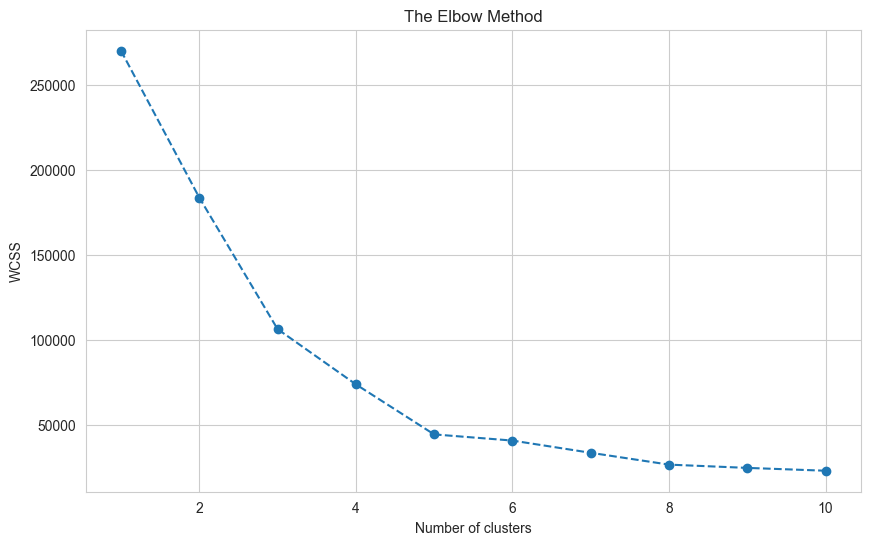

In [4]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

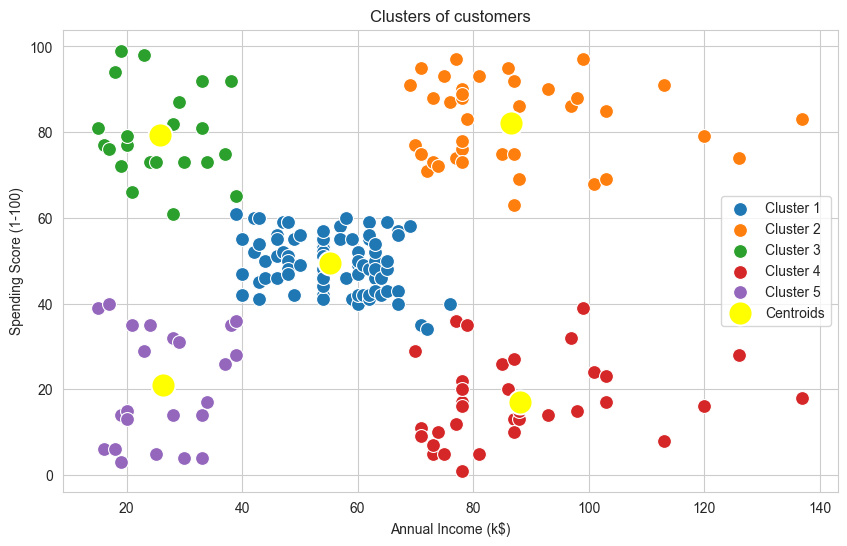

In [6]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(x)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x[y_kmeans == 0, 0], y=x[y_kmeans == 0, 1], s=100, label='Cluster 1')
sns.scatterplot(x=x[y_kmeans == 1, 0], y=x[y_kmeans == 1, 1], s=100, label='Cluster 2')
sns.scatterplot(x=x[y_kmeans == 2, 0], y=x[y_kmeans == 2, 1], s=100, label='Cluster 3')
sns.scatterplot(x=x[y_kmeans == 3, 0], y=x[y_kmeans == 3, 1], s=100, label='Cluster 4')
sns.scatterplot(x=x[y_kmeans == 4, 0], y=x[y_kmeans == 4, 1], s=100, label='Cluster 5')
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], s=300, color='yellow', label='Centroids')
plt.title('Clusters of customers')      
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()